# Customer Churn Prediction

### Notebook summary — Customer Churn Prediction

This notebook prepares the customer churn dataset for modeling. Steps performed (in order):

- Data load
    - Loaded dataset from `customer_churn_data.csv`.
    - Initial preview with `df.head()` and `df.info()` to inspect shape and dtypes.
    - Original dataset size: 10,000 rows.

- Data cleaning / feature removal
    - Dropped non-predictive identifier columns: `RowNumber`, `CustomerId`, `Surname`.

- Exploratory checks and visualizations
    - Checked object-type columns and value counts for categorical features.
    - Visualized distributions with pie charts for:
        - `Geography`
        - `Gender`
        - Target `Exited`

- Categorical encoding
    - Geography:
        - Applied sklearn `OneHotEncoder(drop='first', sparse_output=False)` to `Geography`.
        - Produced `Geography_Germany`, `Geography_Spain`.
        - Concatenated encoded columns to `df` and dropped original `Geography`.
        - Pickled the encoder to `geography_ohe.pkl`.
    - Gender:
        - Applied `OneHotEncoder(drop='first', sparse_output=False)` to `Gender`.
        - Produced `Gender_Male`.
        - Concatenated encoded column to `df` and dropped original `Gender`.
        - Pickled the encoder to `gender_ohe.pkl`.

- Feature / target split
    - Created feature matrix X and target y:
        - X columns after encoding: CreditScore, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Geography_Germany, Geography_Spain, Gender_Male (11 features).
        - y is `Exited`.

- Train / test split
    - Used `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`.
    - Resulting sizes:
        - X_train: 8,000 rows × 11 cols
        - X_test: 2,000 rows × 11 cols
        - y_train: 8,000
        - y_test: 2,000

- Feature scaling
    - Applied `StandardScaler()`:
        - `scaler.fit_transform(X_train)` → `X_train_scaled` (numpy array, shape (8000, 11))
        - `scaler.transform(X_test)` → `X_test_scaled` (numpy array, shape (2000, 11))
        - Pickled scaler to `standard_scaler.pkl`.

- Saved artifacts
    - Pickled objects written during preprocessing:
        - `geography_ohe.pkl` — OneHotEncoder for Geography
        - `gender_ohe.pkl` — OneHotEncoder for Gender
        - `standard_scaler.pkl` — StandardScaler

- Current key variables (examples)
    - df: DataFrame, 10,000 rows × 12 columns (includes `Exited` and encoded columns).
    - X: DataFrame, 10,000 rows × 11 features (listed above).
    - X_train / X_test: DataFrames with 8,000 / 2,000 rows respectively.
    - X_train_scaled / X_test_scaled: numpy.ndarray shapes (8000, 11) / (2000, 11).
    - y, y_train, y_test: target Series (Exited), stratified splits preserved class distribution.

Recommended next steps
- Train classification models (e.g., Logistic Regression, RandomForest, XGBoost) on X_train_scaled and y_train.
- Evaluate on X_test_scaled using accuracy, precision, recall, F1, ROC-AUC; plot confusion matrix and ROC curves.
- Perform hyperparameter tuning (GridSearchCV / RandomizedSearchCV) with cross‑validation.
- Inspect feature importance / coefficients and consider feature engineering.
- Save the final trained model (pickle or joblib) and create an inference pipeline that applies the saved encoders + scaler before prediction.

In [228]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [229]:
import os
import pickle

In [230]:
data_read_path = os.path.join("data", "customer_churn_data.csv")
df = pd.read_csv(data_read_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [231]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Categorical Encoding

Following features does not contribute to the prediction and will be dropped:
- RowNumber
- CustomerId
- Surname

In [232]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [233]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [234]:
# Know feature types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [235]:
# get object features
df.select_dtypes(include=['object'])

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female
...,...,...
9995,France,Male
9996,France,Male
9997,France,Female
9998,Germany,Male


In [236]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

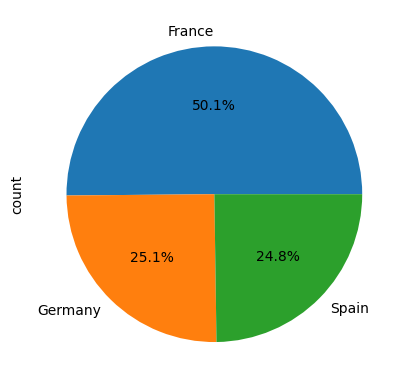

In [237]:
# visualize Geography with pie chart
df['Geography'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

In [238]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

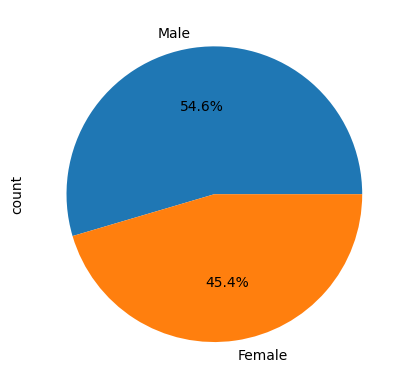

In [239]:
# visualize Gender with pie chart
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

### Encoding Geometry

In [240]:
# one hot encoding for Geography using sklearn
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
geography_encoded = ohe.fit_transform(df[['Geography']])
geography_encoded_df = pd.DataFrame(geography_encoded, columns=ohe.get_feature_names_out(['Geography']))

In [241]:
geography_encoded_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [242]:

df = pd.concat([df, geography_encoded_df], axis=1)
df.drop('Geography', axis=1, inplace=True)

In [243]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,Female,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [244]:
import os

In [245]:
# ensure directory exists and save fitted OneHotEncoder
dir_path = "feature_transformation_artifacts"
os.makedirs(dir_path, exist_ok=True)

# save the OneHotEncoder
pkl_path = os.path.join(dir_path, "geography_ohe.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(ohe, f)

print(f"Saved OneHotEncoder to: {pkl_path}")

Saved OneHotEncoder to: feature_transformation_artifacts/geography_ohe.pkl


### Encoding Gender

In [246]:
# one hot encoding for Gender using sklearn
ohe = OneHotEncoder(sparse_output=False, drop='first')
gender_encoded = ohe.fit_transform(df[['Gender']])
gender_encoded[:5]

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [247]:
gender_encoded_df = pd.DataFrame(gender_encoded, columns=ohe.get_feature_names_out(['Gender']))
gender_encoded_df.head()

,Gender_Male
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [248]:
df = pd.concat([df, gender_encoded_df], axis=1)
df.drop(['Gender'], axis=1, inplace=True)

In [249]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,0.0


In [250]:
dir = "feature_transformation_artifacts"
os.makedirs(dir, exist_ok=True)

file_path = os.path.join(dir, "gender_ohe.pkl")

# pickle the encoder for future use
with open(file_path, "wb") as file:
    pickle.dump(ohe, file)

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_France   10000 non-null  float64
 10  Geography_Germany  10000 non-null  float64
 11  Geography_Spain    10000 non-null  float64
 12  Gender_Male        10000 non-null  float64
dtypes: float64(6), int64(7)
memory usage: 1015.8 KB


In [252]:
# diving data into dependent and independent features
X = df.drop('Exited', axis=1)
y = df['Exited']

In [253]:
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

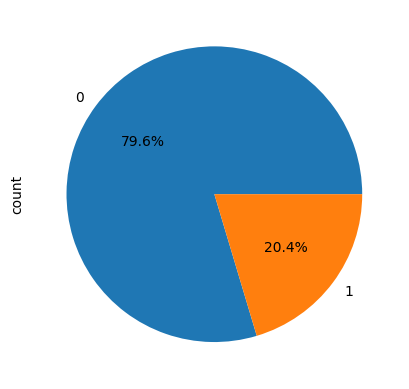

In [254]:
# y data distribution through a pie chart
y.value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

In [255]:
# split data for train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [256]:
y_train.value_counts()

Exited
0    6356
1    1644
Name: count, dtype: int64

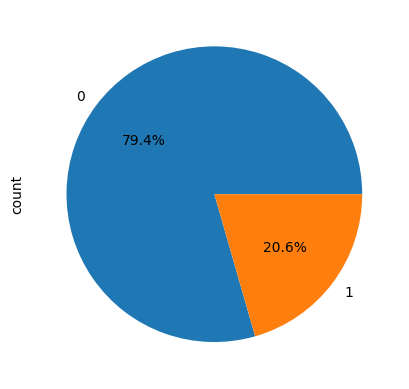

In [257]:
# y_trian distribution through a pie chart
y_train.value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

In [258]:
y_test.value_counts()

Exited
0    1607
1     393
Name: count, dtype: int64

In [259]:
y_train.unique()

array([0, 1])

In [260]:
y_test.unique()

array([0, 1])

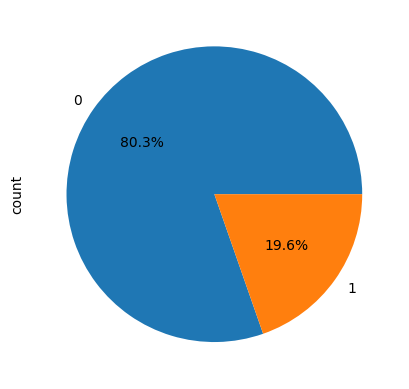

In [261]:
# y_test distribution through a pie chart
y_test.value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

In [262]:
# applying standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [263]:
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

train_data_path = os.path.join(data_dir, "train_data.csv")
test_data_path = os.path.join(data_dir, "test_data.csv")

# create DataFrame for scaled train data with matching index to y_train
train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=y_train.index)
# combine features and target along columns
train_data = pd.concat([train_df, y_train], axis=1)
# save train data to csv (no extra index column)
train_data.to_csv(train_data_path, index=False)

# create DataFrame for scaled test data with matching index to y_test
test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=y_test.index)
test_data = pd.concat([test_df, y_test], axis=1)
test_data.to_csv(test_data_path, index=False)

In [264]:
dir = "feature_transformation_artifacts"
os.makedirs(dir, exist_ok=True)

file_path = os.path.join(dir, "standard_scaler.pkl")

# pickle the scaler for future use
with open(file_path, "wb") as file:
    pickle.dump(scaler, file)